In [1]:
from rabtracks import *

In [2]:
# Open North Atlantic RABTracks
rabt = xr.open_dataset("../RABTracks/RABTracks_NA.nc")
# Subset only 1980-2022, and drop ECMWF-OP-AN that only start in 2006
rabt = clean(rabt.where((rabt.time.dt.year >= 1980) & 
                        (rabt.time.dt.year <= 2022))
            ).drop_sel(source = 'TRACK-ECMWF-OP-AN')
# Subset only cyclones of minimum category TS ib IBTrACS
TS_ids = rabt.sel(source = "IBTrACS").hrcn.trackswhere(
    lambda x: x.usa_wind.max() >= 17
).track_id
rabt = clean(rabt.where(rabt.track_id.isin(TS_ids)))

# 1. Subset BIWE-reaching CTOs

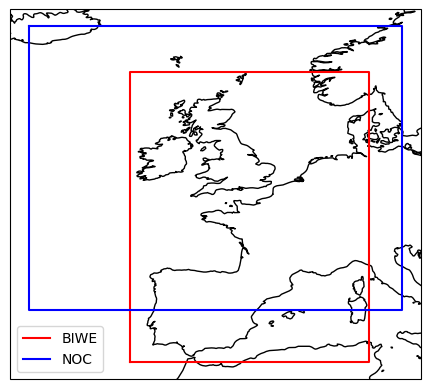

In [3]:
# ======== DEFINE THE BIWE BOX ======== #
biwe_polygon = Polygon(((-11,35.5),(-11,61),(10,61),(10,35.5)))
## plot
ax = plt.axes(projection = ccrs.PlateCarree())
ax.coastlines()
ax.plot(*biwe_polygon.exterior.xy, color = "red", label = "BIWE")

# NOC box defined as alternative
NOC = Polygon(
    (
        (-19.888672, 65.00098),
        (-19.888672, 40.066406),
        (12.888672, 40.066406),
        (12.888672, 65.00098),
    )
)
## plot
ax.plot(*NOC.exterior.xy, color = "blue", label = "NOC")
plt.legend()

# Other option: Filter for points within x km of the coasts enclosed within a box.

In [4]:
# Flag points within the biwe
is_biwe = lambda lon, lat : biwe_polygon.contains(Point(lon, lat))
rabt["in_biwe"] = xr.apply_ufunc(np.vectorize(is_biwe), rabt.lon, rabt.lat)

In [5]:
# Subset of tracks that have at least one point from one source in BIWE
biwe_ids = np.unique(rabt.where(rabt.in_biwe).track_id.astype(str))
rabt_biwe = clean(rabt.where(rabt.track_id.isin(biwe_ids)))

In [6]:
# Number of BIWE point per track per source
N_BIWE = rabt_biwe.to_dataframe().reset_index().groupby(["track_id", "source"]).in_biwe.sum()
N_BIWE = N_BIWE.reset_index().pivot_table(index = "track_id", columns = "source", values = "in_biwe")

In [7]:
# Number of BIWE point per source
N_BIWE.sum().sort_values()

source
IBTrACS           119.0
SyCLoPS-ERA5      388.0
SyCLoPS-MERRA2    440.0
TRACK-MERRA2      501.0
TRACK-NCEP        537.0
TRACK-ERA5        547.0
TRACK-JRA3Q       558.0
SyCLoPS-JRA3Q     607.0
dtype: float64

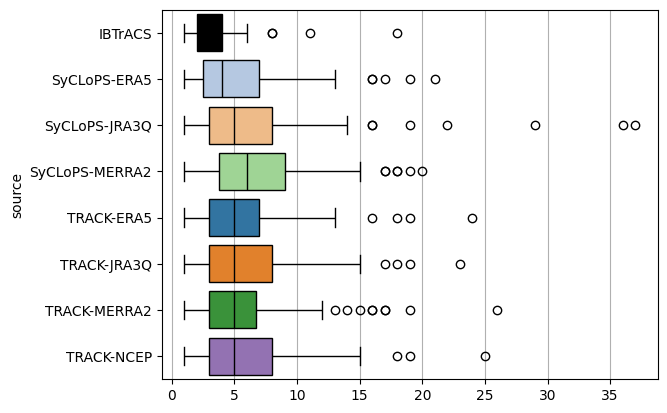

In [8]:
# Number of BIWE points per track (when there is at least one)
sns.boxplot(data = N_BIWE[N_BIWE > 0], palette= PALETTE, orient = "h")
plt.grid(axis = 'x')

In [9]:
with open("RABTracks_BIWE.pkl", "wb") as f:
    pkl.dump(rabt_biwe, f)

# 2. Climatology of BIWE-reaching CTOs

In [10]:
with open("RABTracks_BIWE.pkl", "rb") as f:
    rabt_biwe = pkl.load(f)

## Number of BIWE-reaching CTO per year

In [11]:
# Number of BIWE point per track per source
tid_in_biwe = rabt_biwe.to_dataframe().reset_index().groupby(["track_id", "source"]).in_biwe.max()
tid_in_biwe = tid_in_biwe.reset_index().pivot_table(index = "track_id", columns = "source", values = "in_biwe")

In [12]:
# Compute year for each track id
tid_in_biwe["year"] = tid_in_biwe.index.str.slice(0,4).astype(int)

<Axes: xlabel='year'>

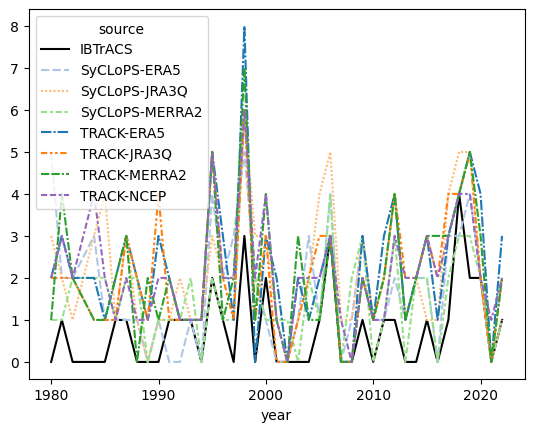

In [13]:
# Number of BIWE CTO per year for each source
sns.lineplot(tid_in_biwe.groupby("year").sum(), palette = PALETTE,)

In [14]:
# Compute the confidence level for each track id
conf_level_per_tid = tid_in_biwe[rabt_biwe.source.values].sum(axis = 1)

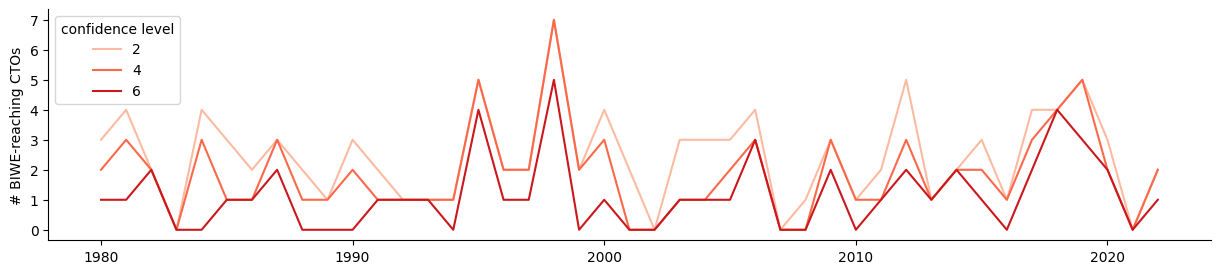

In [15]:
# Number of BIWE-reaching CTOs depending on the imposed confidence level
df = pd.DataFrame(conf_level_per_tid.rename("conf_level"))
df["year"] = df.index.str.slice(0,4).astype(int)

CLs = [2,4,6]
sns.set_palette("Reds", len(CLs))
fig = plt.figure(figsize = (15,3))
ax = plt.axes()
for cl in CLs:
    N_per_year_cl = df[df.conf_level >= cl].groupby("year").count().join(pd.DataFrame(index = np.arange(1980,2023)), how = "right").fillna(0)
    N_per_year_cl.plot(ax = ax, label = cl)
plt.legend(CLs, title = "confidence level")
plt.ylabel("# BIWE-reaching CTOs")
sns.despine()

In [16]:
# Mean number of BIWE-reaching CTO depending on the confidence level
{cl: float(df[df.conf_level >= cl].groupby("year").count().join(pd.DataFrame(index = np.arange(1980,2023)), how = "right").fillna(0).mean().values[0].round(2)) for cl in range(1,9)}

{1: 3.63, 2: 2.47, 3: 2.07, 4: 1.88, 5: 1.49, 6: 1.16, 7: 0.93, 8: 0.56}

## Seasonality

In [17]:
conf_level_per_tid[conf_level_per_tid >= 2].index

Index(['1980245N16322', '1980249N18336', '1980275N34340', '1981127N18276',
       '1981255N14311', '1981265N14328', '1981317N31286', '1982169N26274',
       '1982257N20291', '1984253N29283',
       ...
       '2019246N16330', '2019256N23286', '2019266N11341', '2019297N40322',
       '2019323N19302', '2020186N30289', '2020256N11329', '2020259N47338',
       '2022154N21273', '2022244N38313'],
      dtype='object', name='track_id', length=106)

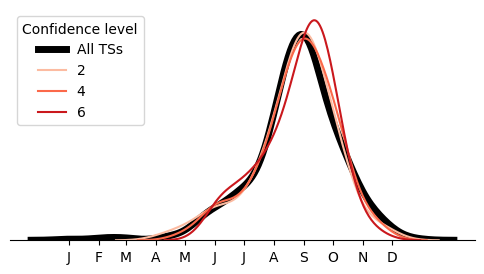

In [18]:
plt.figure(figsize = (6,3))
ax = sns.kdeplot(rabt.hrcn.get_gen_vals().time.dt.dayofyear, color = 'k', 
                 linewidth = 5, label = "All TSs")
CLs = [2,4,6]
sns.set_palette("Reds", len(CLs))
for cl in CLs:
    ids_cl = conf_level_per_tid[conf_level_per_tid >= cl].index
    rabt_biwe_cl = rabt_biwe.where(rabt_biwe.track_id.isin(ids_cl))
    doys = rabt_biwe_cl.hrcn.get_gen_vals().time.dt.dayofyear
    sns.kdeplot(doys, label = cl)

plt.legend(title = "Confidence level")
plt.xticks([1, 32, 60, 91, 121, 152, 182, 213, 244, 274, 305, 335], 
           "JFMAMJJASOND")
ax.get_yaxis().set_visible(False)
sns.despine(left = True)

## Intensity

In [19]:
# Build a dataframe with only the points in BIWE
rabt_biwe_in_biwe_df = rabt_biwe.to_dataframe()
rabt_biwe_in_biwe_df = rabt_biwe_in_biwe_df[rabt_biwe_in_biwe_df.in_biwe.astype(bool)]

<Axes: xlabel='pres', ylabel='Density'>

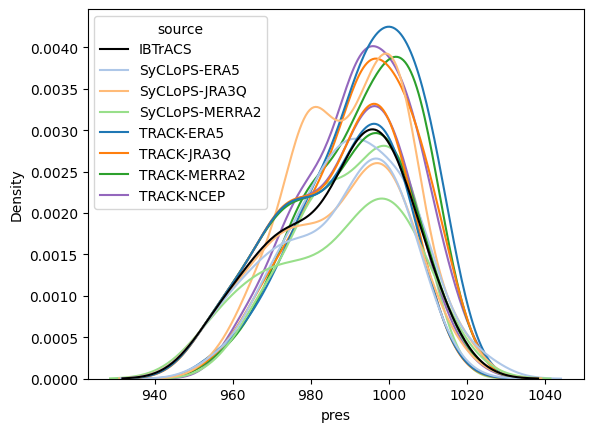

In [20]:
# Compute minimum pressure in BIWE per source
# Non-IBTrACs
min_pres = rabt_biwe_in_biwe_df.reset_index().groupby(["source", "track_id"]).pres.min().reset_index()
sns.kdeplot(data = min_pres, x = "pres", hue = "source", palette = PALETTE)
# IBTrACS
min_pres = rabt_biwe_in_biwe_df.reset_index().groupby(["source", "track_id"]).usa_pres.min().reset_index()
sns.kdeplot(data = min_pres, x = "usa_pres", hue = "source", palette = PALETTE)

<Axes: xlabel='wind10', ylabel='Density'>

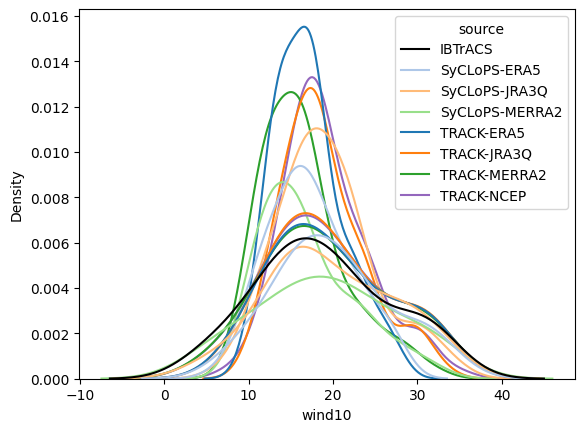

In [21]:
# Compute Maximum wind in BIWE per source
# Non-IBTrACs
max_wind = rabt_biwe_in_biwe_df.reset_index().groupby(["source", "track_id"]).wind10.max().reset_index()
sns.kdeplot(data = max_wind, x = "wind10", hue = "source", palette = PALETTE)
# IBTrACS
max_wind = rabt_biwe_in_biwe_df.reset_index().groupby(["source", "track_id"]).usa_wind.min().reset_index()
sns.kdeplot(data = max_wind, x = "usa_wind", hue = "source", palette = PALETTE)

## Entry point in BIWE box

In [22]:
entry_points = rabt_biwe_in_biwe_df.reset_index().sort_values("time").groupby(["track_id", "source"]).first()

<Axes: xlabel='Density', ylabel='lat'>

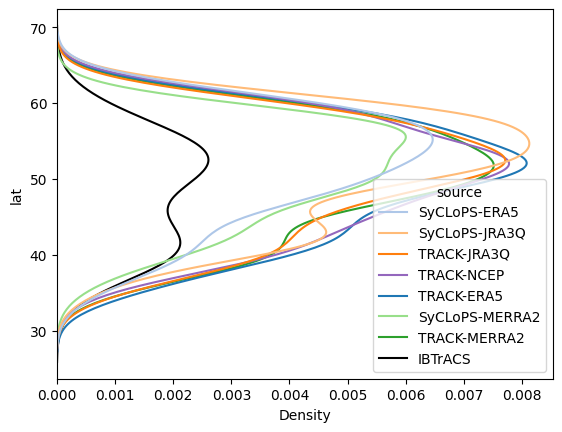

In [23]:
sns.kdeplot(data = entry_points.reset_index(), y = "lat", hue = "source", palette= PALETTE)

In [24]:
entry_lat_per_CL = pd.DataFrame(entry_points.reset_index().groupby("track_id").lat.mean().rename("entry_lat")).join(conf_level_per_tid.rename("CL"))

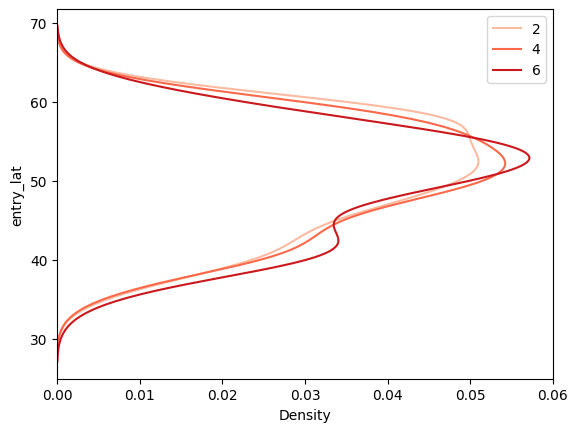

In [25]:
CLs = [2,4,6]
sns.set_palette("Reds", len(CLs))
for cl in CLs:
    sns.kdeplot(y = entry_lat_per_CL[entry_lat_per_CL.CL >= cl].entry_lat, 
                label = cl)
plt.legend()

# 3. Cases of BIWE-reaching CTOs

## Most confident BIWE-reaching CTOs

In [26]:
def plot_one_cyclone_panel(
    ax,
    track,
    palette: dict,
    eib_dir: str = "../RABTracks",
    add_coastlines: bool = True,
    add_title: bool = True,
    handles_dict: dict | None = None,
):
    """
    Draw a single cyclone track panel on `ax` (a Cartopy GeoAxes).

    Parameters
    ----------
    ax : cartopy.mpl.geoaxes.GeoAxesSubplot
        Axis to draw into (created with projection=ccrs.PlateCarree()).
    name, year, basin : str, int, str
        Cyclone identifier and basin (e.g., 'NA', 'EP', 'SI').
    palette : dict
        Mapping {source_name: color}. Must include the sources present in the dataset.
    eib_dir : str
        Directory containing RABTracks_{basin}.nc files.
    handles_dict : dict | None
        If provided, gets populated with one Line2D per source (for a shared legend),
        but only the first time each source is seen. If None, a new dict is used.

    Returns
    -------
    handles_dict : dict
        Mapping {source_name: Line2D}, suitable for building a legend.
    track : xarray.Dataset
        The cyclone subset (all sources).
    track_ib : xarray.Dataset
        The IBTrACS-only subset with valid lon/lat (kept for parity with your original code).
    """
    if handles_dict is None:
        handles_dict = {}

    # Extract data for given cyclone
    track_ib = (
        track.sel(source="IBTrACS")
        .where(~np.isnan(track.sel(source="IBTrACS").lon), drop=True)
    )

    # Plot all sources present
    for ds in track.source.values:
        k = track.sel(source=ds).squeeze()

        if (~np.isnan(k.lon)).sum() > 0:
            mask = ~np.isnan(k.lon) & ~np.isnan(k.lat)
            lon = k.lon[mask]
            lat = k.lat[mask]

            lw = 5 if ds == "IBTrACS" else None
            line, = ax.plot(
                lon,
                lat,
                color=palette[ds],
                lw=lw,
                label=ds,
                transform=ccrs.PlateCarree(),
            )

            if ds not in handles_dict:
                handles_dict[ds] = line

    if add_coastlines:
        ax.coastlines(color="grey")
    if add_title:
        name = track_ib.name.max().values
        year = track_ib.time.dt.year.max().values
        ax.set_title(f"{name} ({year})")

    #return handles_dict, track, track_ib

/tmp/ipykernel_7022/2096113888.py:4: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


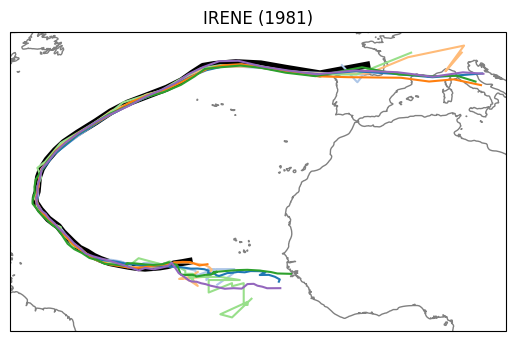

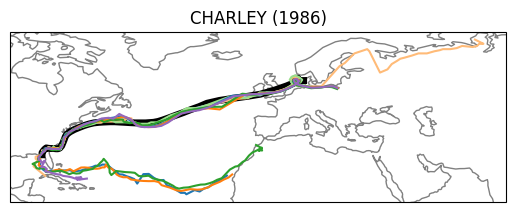

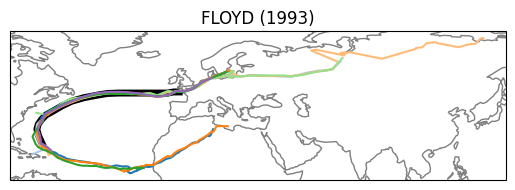

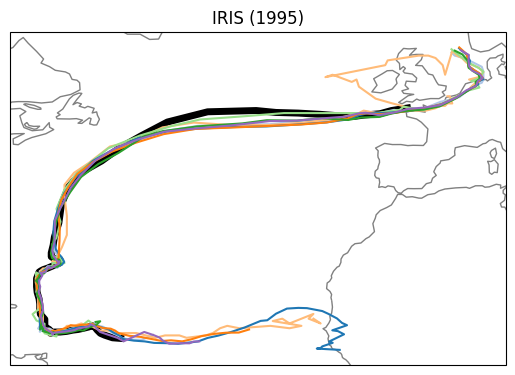

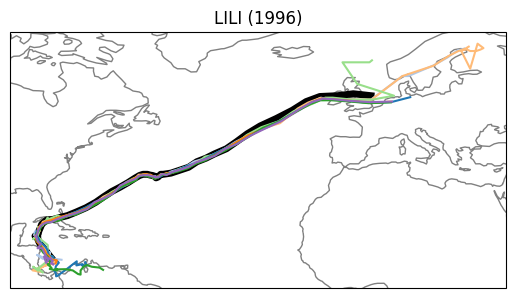

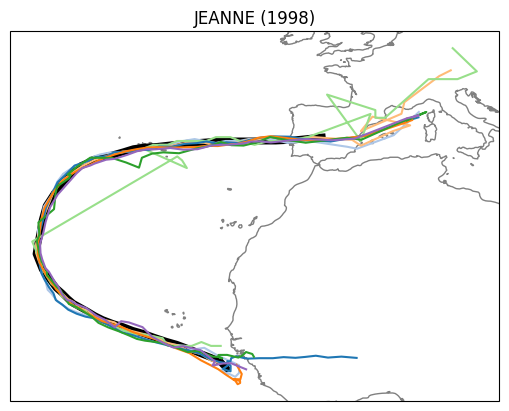

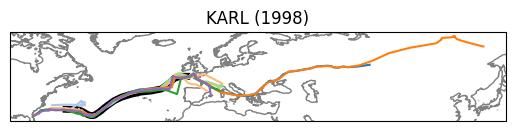

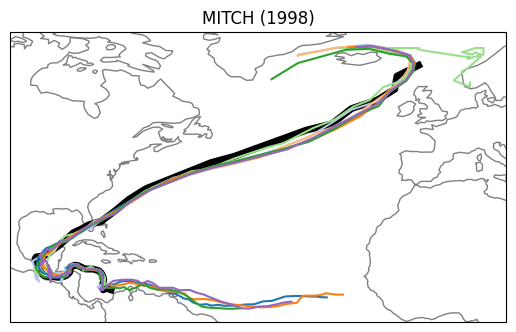

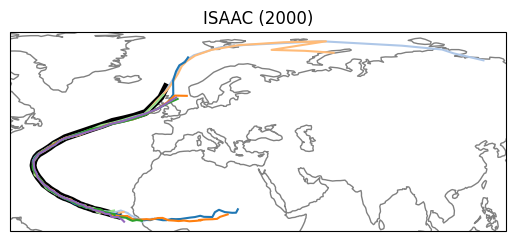

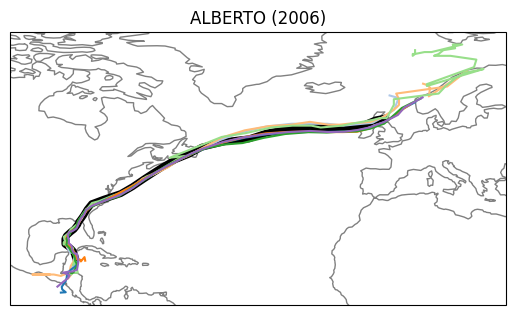

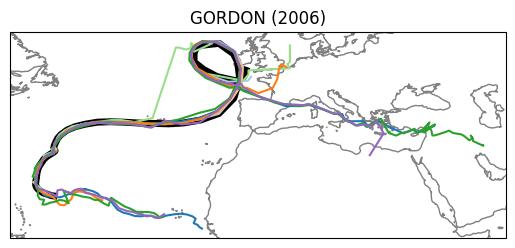

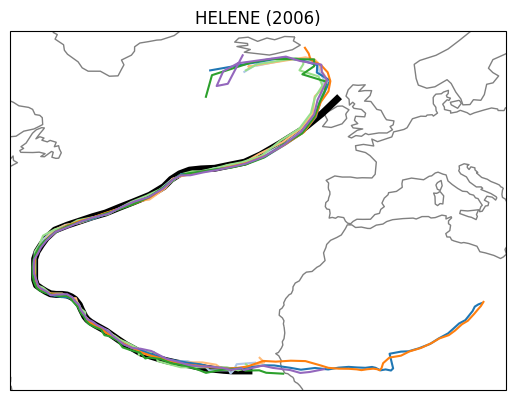

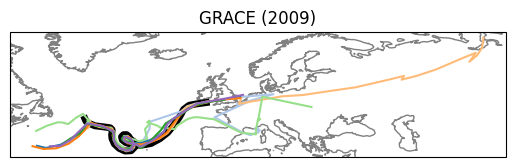

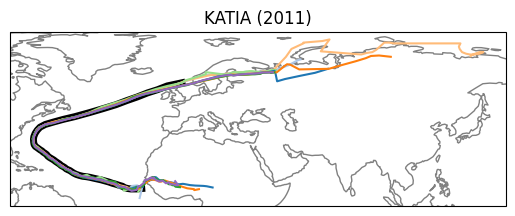

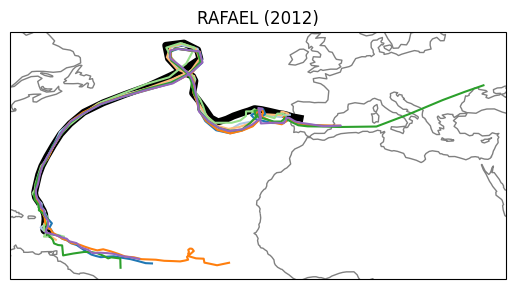

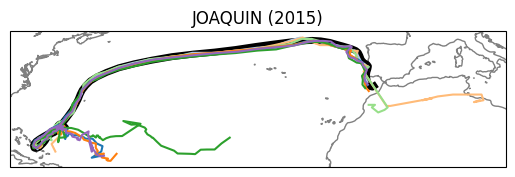

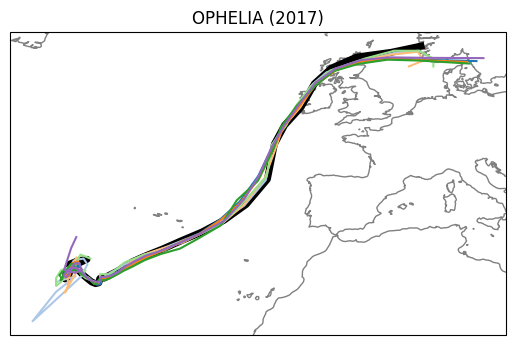

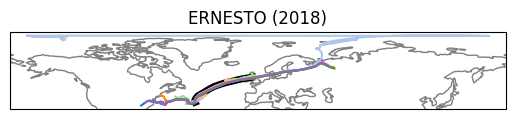

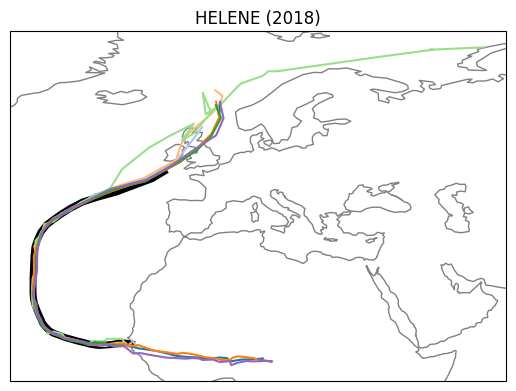

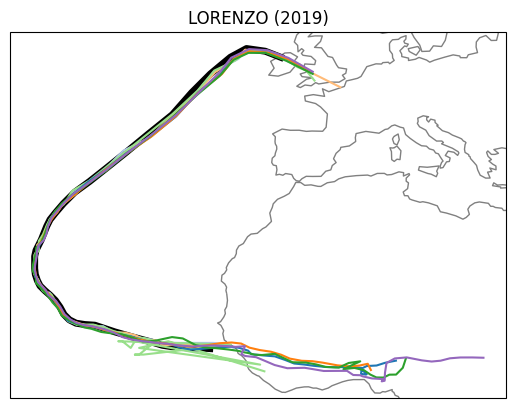

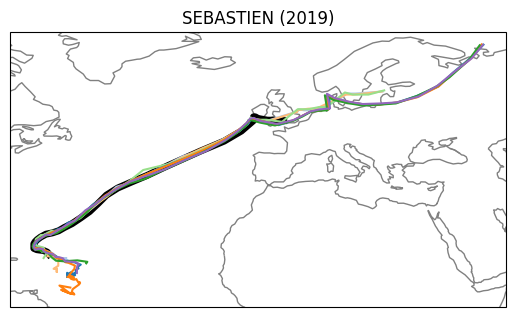

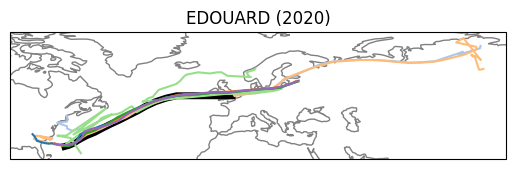

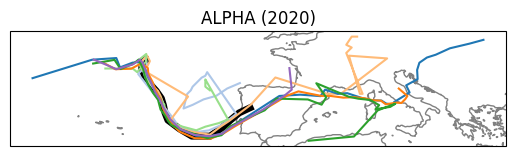

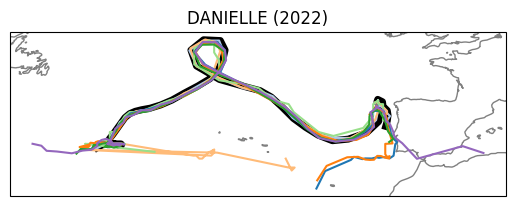

In [27]:
cl8_tids = conf_level_per_tid[conf_level_per_tid >= 8].index

for tid in cl8_tids :
    plt.figure()
    ax = plt.axes(projection = ccrs.PlateCarree())
    plot_one_cyclone_panel(
        ax,
        rabt_biwe.where(rabt_biwe.track_id == tid),
        palette = PALETTE
    )

# 4. Worst BIWE-reaching CTOs

## Worst IBTrACS/reanalysis wind

In [28]:
rabt_biwe_in_biwe_df["wind10"] = np.where(rabt_biwe_in_biwe_df["wind10"].isna(), rabt_biwe_in_biwe_df.usa_wind, rabt_biwe_in_biwe_df["wind10"])

In [29]:
rabt_biwe_in_biwe_df.reset_index().sort_values("wind10", ascending = False
                ).groupby("track_id").first().sort_values("wind10", ascending = False
                )[["source", "wind10", "name", "time"]].head(5)

,source,wind10,name,time
track_id,,,,
1993251N25293,IBTrACS,36.011080,FLOYD,1993-09-12 12:00:00
1984267N31302,SyCLoPS-JRA3Q,34.806129,HORTENSE,1984-10-04 12:00:00
1995235N13311,IBTrACS,33.438860,IRIS,1995-09-07 00:00:00
2017280N32321,IBTrACS,33.438860,OPHELIA,2017-10-16 12:00:00
1998295N12284,SyCLoPS-MERRA2,32.249599,MITCH,1998-11-09 12:00:00


## Worst IBTrACS/reanalysis pressure

In [30]:
rabt_biwe_in_biwe_df["pres"] = np.where(rabt_biwe_in_biwe_df["pres"].isna(), rabt_biwe_in_biwe_df.usa_pres, rabt_biwe_in_biwe_df["pres"])

In [31]:
rabt_biwe_in_biwe_df.reset_index().sort_values("pres", ascending = True
        ).groupby("track_id").first().sort_values("pres", ascending = True
        )[["source", "pres", "name", "time"]].head(5)

,source,pres,name,time
track_id,,,,
1998295N12284,TRACK-ERA5,954.815430,MITCH,1998-11-09 12:00:00
1995235N13311,IBTrACS,957.000000,IRIS,1995-09-07 00:00:00
2017280N32321,IBTrACS,959.000000,OPHELIA,2017-10-16 12:00:00
2000279N29279,TRACK-ERA5,962.710571,LESLIE,2000-10-11 06:00:00
2005217N13327,SyCLoPS-JRA3Q,964.582703,IRENE,2005-08-24 06:00:00


## Slowest movement

In [32]:
rabt_biwe_in_biwe_df.reset_index().sort_values("translation_speed_roll", ascending = True
        ).groupby("track_id").first().sort_values("translation_speed_roll", ascending = True
        )[["source", "translation_speed_roll", "name", "time"]].head(5)

,source,translation_speed_roll,name,time
track_id,,,,
1991228N26286,SyCLoPS-MERRA2,0.000000,BOB,1991-08-30 18:00:00
2022244N38313,TRACK-JRA3Q,0.512317,DANIELLE,2022-09-17 00:00:00
2021165N32282,TRACK-NCEP,0.530024,BILL,2021-06-22 12:00:00
1986226N30276,IBTrACS,0.600719,CHARLEY,1986-08-28 12:00:00
2014210N10323,TRACK-ERA5,0.602741,BERTHA,2014-08-12 06:00:00


## Compound events

In [33]:
wind_min = rabt_biwe_in_biwe_df.wind10.min()
wind_max = rabt_biwe_in_biwe_df.wind10.max()
rabt_biwe_in_biwe_df["wind_norm"] = (rabt_biwe_in_biwe_df.wind10 - wind_min) / (wind_max-wind_min)

In [34]:
pres_min = rabt_biwe_in_biwe_df.pres.min()
pres_max = rabt_biwe_in_biwe_df.pres.max()
rabt_biwe_in_biwe_df["pres_norm"] = (pres_max - rabt_biwe_in_biwe_df.pres) / (pres_max-pres_min)

In [35]:
ts_min = rabt_biwe_in_biwe_df.translation_speed_roll.min()
ts_max = rabt_biwe_in_biwe_df.translation_speed_roll.max()
rabt_biwe_in_biwe_df["ts_norm"] = (ts_max - rabt_biwe_in_biwe_df.translation_speed_roll) / (ts_max-ts_min)

In [36]:
rabt_biwe_in_biwe_df["compound_index"] = rabt_biwe_in_biwe_df.wind_norm * rabt_biwe_in_biwe_df.pres_norm * rabt_biwe_in_biwe_df.ts_norm

In [37]:
worst_compounds = rabt_biwe_in_biwe_df.reset_index().sort_values("compound_index", ascending = False
                ).groupby("track_id").first().sort_values("compound_index", ascending = False
                )[["source", "compound_index", "wind10", "pres", "translation_speed_roll", "name", "time"]].head(10)
worst_compounds

,source,compound_index,wind10,pres,translation_speed_roll,name,time
track_id,,,,,,,
1993251N25293,TRACK-NCEP,0.604873,30.253599,965.970703,4.038880,FLOYD,1993-09-13 00:00:00
1995235N13311,SyCLoPS-JRA3Q,0.569812,29.590969,960.292297,6.938748,IRIS,1995-09-07 00:00:00
1984267N31302,SyCLoPS-JRA3Q,0.552294,34.806129,969.367676,8.398727,HORTENSE,1984-10-04 12:00:00
1998295N12284,SyCLoPS-MERRA2,0.517296,32.249599,957.525879,11.561137,MITCH,1998-11-09 12:00:00
2017280N32321,IBTrACS,0.480766,33.438860,959.000000,13.123250,OPHELIA,2017-10-16 12:00:00
2005217N13327,SyCLoPS-JRA3Q,0.462181,28.039591,964.582703,8.757975,IRENE,2005-08-24 06:00:00
1980249N18336,SyCLoPS-JRA3Q,0.441089,29.612560,971.891174,8.477389,EARL,1980-09-12 06:00:00
2002264N28308,SyCLoPS-MERRA2,0.418358,23.380180,966.658325,5.709135,KYLE,2002-10-23 18:00:00
2014210N10323,TRACK-NCEP,0.413216,26.080851,976.809021,4.688169,BERTHA,2014-08-11 06:00:00


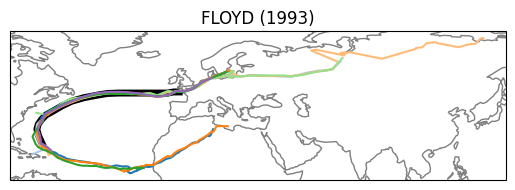

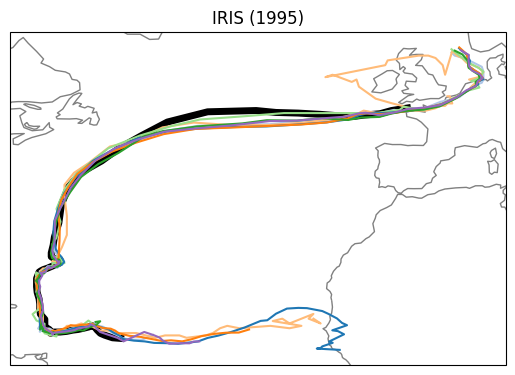

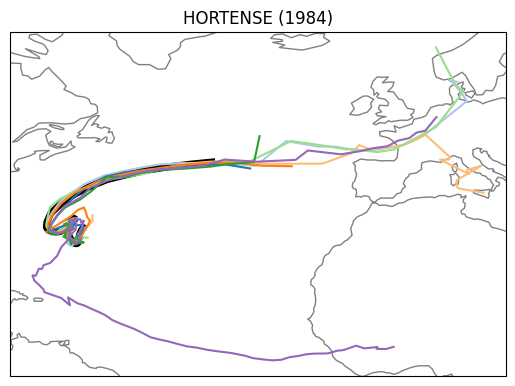

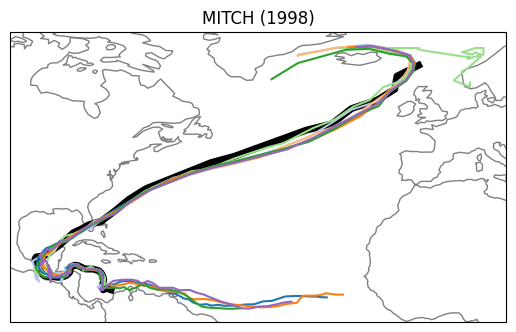

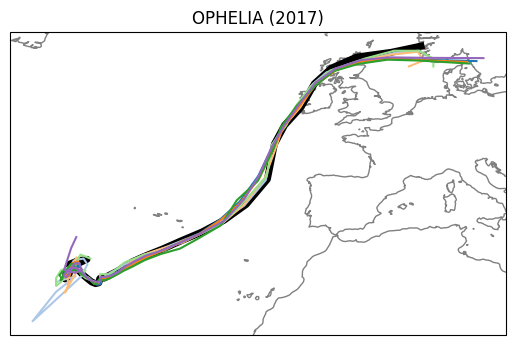

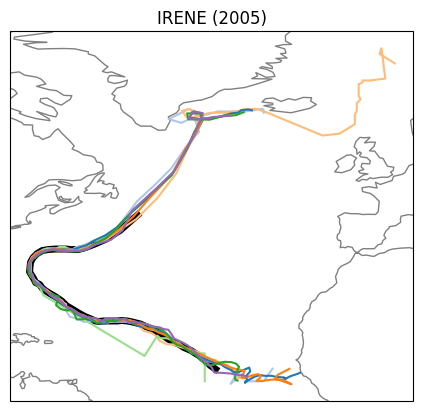

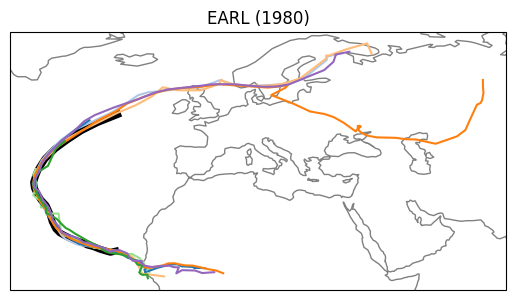

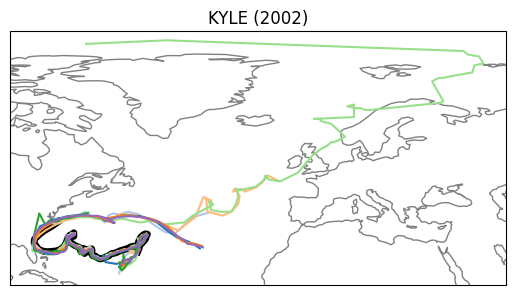

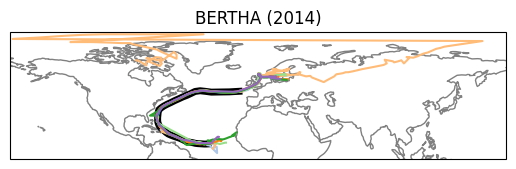

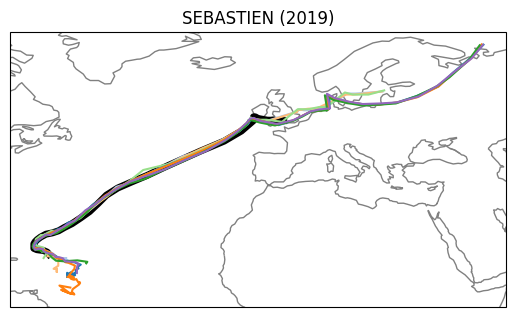

In [38]:
worst_tids = worst_compounds.index

for tid in worst_tids:
    plt.figure()
    ax = plt.axes(projection = ccrs.PlateCarree())
    plot_one_cyclone_panel(
        ax,
        rabt_biwe.where(rabt_biwe.track_id == tid),
        palette = PALETTE
    )